In [ ]:
# Import required libraries
from sklearn.datasets import load_iris                     # Load built-in Iris dataset
from sklearn.model_selection import train_test_split       # For splitting the dataset
from sklearn.ensemble import AdaBoostClassifier            # Import AdaBoost Classifier
from sklearn.tree import DecisionTreeClassifier            # Base estimator (default is decision stump)
from sklearn.metrics import accuracy_score, classification_report  # For evaluation
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [ ]:
# Load the Iris dataset
iris = load_iris()

In [ ]:
# Features and target labels
X = iris.data          # Feature matrix (150 samples, 4 features)
y = iris.target        # Target labels (3 classes)

In [ ]:
# Split data into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Initialize a weak learner (base estimator) – decision stump (depth=1)
base_estimator = DecisionTreeClassifier(max_depth=1)

In [ ]:
# Create the AdaBoost classifier
ada = AdaBoostClassifier(
    estimator=base_estimator,        # Use shallow decision trees as weak learners
    n_estimators=50,                 # Number of boosting rounds / weak learners
    learning_rate=1.0,               # Controls contribution of each weak learner
    random_state=42
)

In [ ]:
# Train the AdaBoost model
ada.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   random_state=42)

In [ ]:
# Predict on the test data
y_pred = ada.predict(X_test)

In [ ]:
# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"AdaBoost Classifier Accuracy: {accuracy * 100:.2f}%")

AdaBoost Classifier Accuracy: 93.33%


In [ ]:
# Print classification metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.89      0.89         9
   virginica       0.91      0.91      0.91        11

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



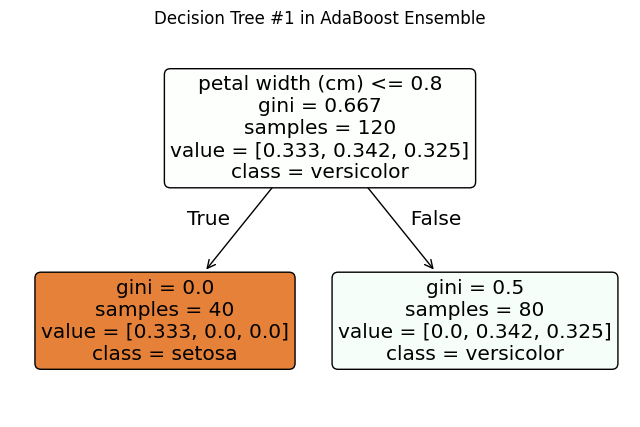

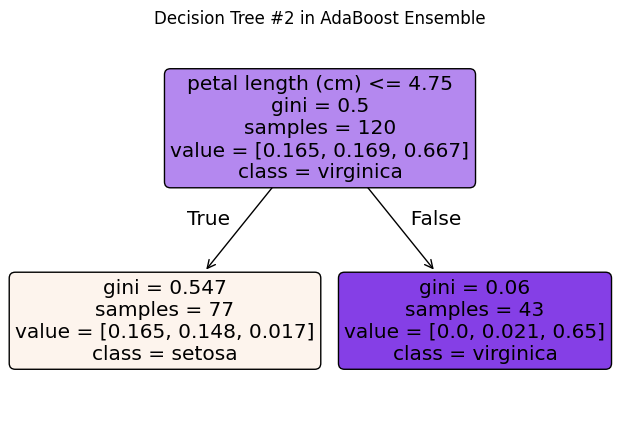

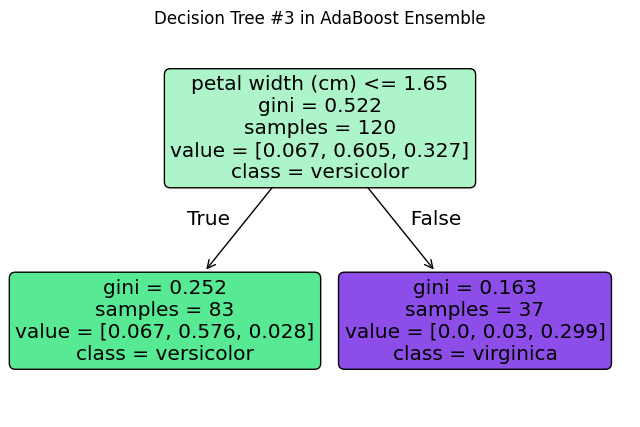

In [ ]:
# Let's visualize the first 3 decision trees in the AdaBoost ensemble
for i in range(3):
    estimator = ada.estimators_[i]  # Get the i-th weak learner
    plt.figure(figsize=(8, 5))
    plot_tree(estimator,
              filled=True,
              feature_names=iris.feature_names,
              class_names=iris.target_names,
              rounded=True)
    plt.title(f"Decision Tree #{i+1} in AdaBoost Ensemble")
    plt.show()